# Landsat 8 OLI Level-2 download for Alegre, Brazil

This notebook uses the [USGS Landsat Collection 2 Level-2 dataset on AWS](https://registry.opendata.aws/usgs-landsat/index.html)
to locate and download surface reflectance bands (B2/B3/B4) covering Alegre, Espírito Santo, Brazil
for the selected July 2025 date. The workflow queries the LandsatLook STAC API with your token and then pulls
the requested assets directly from the public `usgs-landsat` S3 bucket.


In [107]:
from pathlib import Path
import os
import json
import boto3
from botocore.config import Config
from botocore import UNSIGNED

import requests

target_latitude = -19.3949 #-20.7589
target_longitude =-40.0643 # -41.5387
spatial_buffer_degrees = 1 # 0.05
start_time_iso = "2025-01-01T00:00:00Z"
end_time_iso = "2025-10-20T00:00:00Z"
bbox = [
    target_longitude - spatial_buffer_degrees,
    target_latitude - spatial_buffer_degrees,
    target_longitude + spatial_buffer_degrees,
    target_latitude + spatial_buffer_degrees,
]

stac_api_root = "https://landsatlook.usgs.gov/stac-server"
collection_id = "landsat-c2l2"
local_download_dir = Path('../data') / 'landsat' / 'linhares_2025-07-01'
local_download_dir.mkdir(parents=True, exist_ok=True)
s3_bucket_name = 'usgs-landsat'
s3_client = boto3.client('s3', config=Config(signature_version=UNSIGNED))

landsatlook_token = os.environ.get('LANDSATLOOK_TOKEN')
if not landsatlook_token:
    raise RuntimeError('Set LANDSATLOOK_TOKEN in your environment to access landsatlook.usgs.gov.')
stac_headers = {'Authorization': f'Bearer {landsatlook_token}'}

requested_assets = [
    'reduced_resolution_browse',
    'B2', 'B3', 'B4',
    'qa_pixel'
]
print(start_time_iso,end_time_iso)

2025-01-01T00:00:00Z 2025-10-20T00:00:00Z


reduced_resolution_browse (true-color JPEG at ~300 m resolution) 

nir08: Near-infrared band (0.85–0.88 µm). Highly reflective for healthy vegetation, so it’s the key input for NDVI-style indices and helps delineate forest cover and canopy vigor.

swir16: Shortwave infrared band around 1.6 µm. Sensitive to moisture and lignin/cellulose content, making it useful for assessing vegetation and soil moisture and distinguishing bare soil vs. forest.

swir22: Longer SWIR band near 2.2 µm. Strongly influenced by water content and mineralogy, helping separate forested areas from dry soils or burned surfaces and improving biomass assessments.

qa_pixel: Pixel quality assurance bitmask. Encodes per-pixel flags such as clouds, cloud shadows, snow/ice, and fill values so you can mask unreliable pixels before analysis.

In [108]:
search_url = f"{stac_api_root}/search"
search_payload = {
    'bbox': bbox,
    'collections': [collection_id],
    'datetime': f"{start_time_iso}/{end_time_iso}",
    'limit': 5,
    'sortby': [{
        'field': 'properties.datetime',
        'direction': 'asc',
    }],
}
print(search_payload)
print(search_url)
stac_response = requests.post(search_url, json=search_payload, headers=stac_headers, timeout=90)
stac_response.raise_for_status()
stac_json = stac_response.json()
features = stac_json.get('features', [])
if not features:
    raise RuntimeError('No matching Landsat 8 scenes for this place and time.')
chosen_feature = features[0]
chosen_id = chosen_feature['id']
chosen_datetime = chosen_feature['properties']['datetime']
path_value = chosen_feature['properties'].get('wrs_path')
row_value = chosen_feature['properties'].get('wrs_row')
path_row = f"{path_value:03d}/{row_value:03d}" if path_value is not None and row_value is not None else 'unknown'
available_assets = list(chosen_feature['assets'].keys())
print('Scene ID:', chosen_id)
print('Acquisition datetime:', chosen_datetime)
print('WRS Path/Row:', path_row)
print('Available asset keys:', ', '.join(available_assets))


{'bbox': [-41.0643, -20.3949, -39.0643, -18.3949], 'collections': ['landsat-c2l2'], 'datetime': '2025-01-01T00:00:00Z/2025-10-20T00:00:00Z', 'limit': 5, 'sortby': [{'field': 'properties.datetime', 'direction': 'asc'}]}
https://landsatlook.usgs.gov/stac-server/search


RuntimeError: No matching Landsat 8 scenes for this place and time.

In [65]:
requested_assets

['reduced_resolution_browse']

In [58]:
assets_to_fetch = []
for asset_key in requested_assets:
    if asset_key in chosen_feature['assets']:
        assets_to_fetch.append((asset_key, chosen_feature['assets'][asset_key]['href']))
if not assets_to_fetch:
    raise RuntimeError('None of the requested asset keys are available in the selected STAC item.')
download_manifest = []
for asset_name, asset_href in assets_to_fetch:
    object_key = None
    if asset_href.startswith('s3://usgs-landsat/'):
        object_key = asset_href.replace('s3://usgs-landsat/', '')
    elif asset_href.startswith('http') and 'landsatlook.usgs.gov' in asset_href:
        parts = asset_href.split('/data/', 1)
        if len(parts) == 2:
            object_key = parts[1].lstrip('/')
    if not object_key:
        raise ValueError(f'Unsupported asset location: {asset_href}')
    download_reference = f"s3://{s3_bucket_name}/{object_key}"
    destination = local_download_dir / Path(object_key).name
    print(f"Downloading {asset_name} from {download_reference}")
    print(f"s3_client.download_file(Bucket={s3_bucket_name!r}, Key={object_key!r}, Filename={destination.as_posix()!r})")
    s3_client.download_file(
        s3_bucket_name,
        object_key,
        destination.as_posix(),
        ExtraArgs={"RequestPayer": "requester"}
    )
    download_manifest.append({
        'asset': asset_name,
        'path': destination.as_posix(),
        'size_bytes': destination.stat().st_size,
    })
print(json.dumps(download_manifest, indent=2))


s3_client.download_file(Bucket='usgs-landsat', Key='collection02/level-1/standard/oli-tirs/2025/098/170/LC08_L1GT_098170_20250802_20250808_02_T2/LC08_L1GT_098170_20250802_20250808_02_T2_thumb_large.jpeg', Filename='../data/landsat/alegre_2025-08-01/LC08_L1GT_098170_20250802_20250808_02_T2_reduced_resolution_browse.jpeg')
[
  {
    "asset": "reduced_resolution_browse",
    "path": "../data/landsat/alegre_2025-08-01/LC08_L1GT_098170_20250802_20250808_02_T2_reduced_resolution_browse.jpeg",
    "size_bytes": 9813
  }
]


Level-2 requester-pays downloads typically take a few seconds per band (B2/B3/B4 plus QA) depending on your bandwidth.


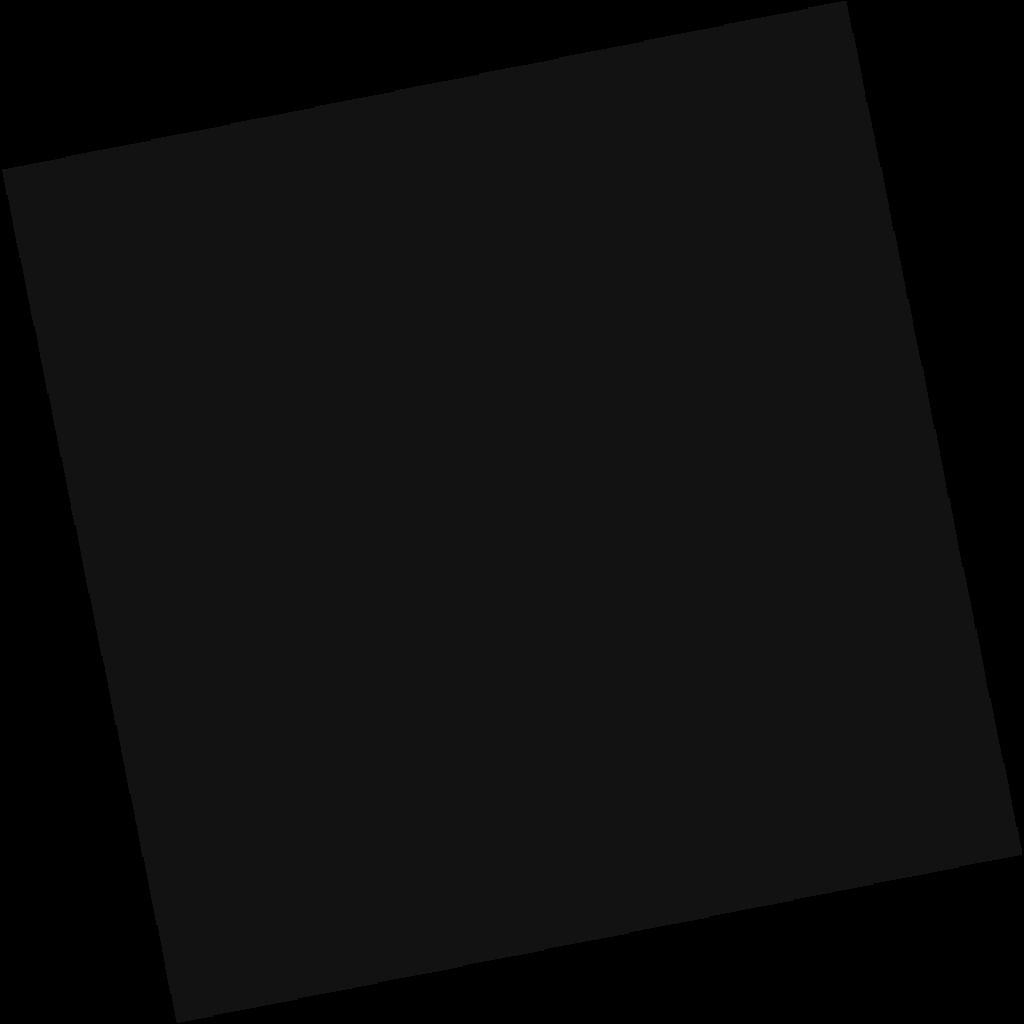

In [60]:
from PIL import Image
from IPython.display import display
from pathlib import Path

if 'download_manifest' not in globals():
    raise RuntimeError('Run the download cell before trying to show the browse image.')
browse_entry = next((item for item in download_manifest if item['asset'] == 'reduced_resolution_browse'), None)
if not browse_entry:
    raise RuntimeError("'reduced_resolution_browse' was not downloaded. Add it to requested_assets and rerun the download cell.")
browse_image = Path(browse_entry['path'])
if not browse_image.exists():
    raise FileNotFoundError(f'Expected browse image not found at {browse_image}')
display(Image.open(browse_image))


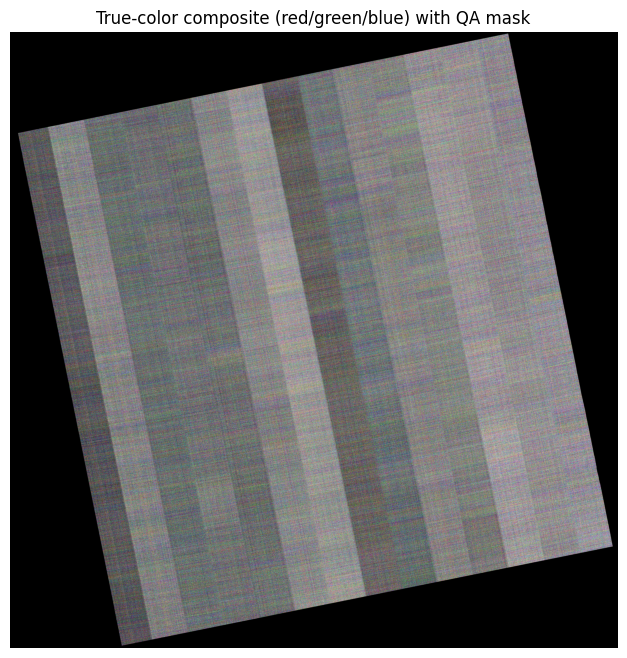

In [76]:
import numpy as np
import rasterio
from matplotlib import pyplot as plt
from pathlib import Path

if 'download_manifest' not in globals():
    raise RuntimeError('Run the download cell before building the RGB composite.')
asset_lookup = {entry['asset']: Path(entry['path']) for entry in download_manifest}
def resolve_asset(*candidates):
    for candidate in candidates:
        if candidate in asset_lookup:
            return asset_lookup[candidate]
    raise FileNotFoundError(f"Missing expected asset in download_manifest: {candidates}")
band_assets = {
    'red': ('B4', 'red'),
    'green': ('B3', 'green'),
    'blue': ('B2', 'blue'),
}
band_arrays = {}
for color, candidates in band_assets.items():
    band_path = resolve_asset(*candidates)
    if not band_path.exists():
        raise FileNotFoundError(f'Missing {color} band at {band_path}. Download the band before building the RGB composite.')
    with rasterio.open(band_path) as src:
        band_arrays[color] = src.read(1).astype('float32')
qa_path = resolve_asset('qa_pixel', 'QA_PIXEL')
if not qa_path.exists():
    raise FileNotFoundError(f'Missing QA band at {qa_path}. Download qa_pixel before building the RGB composite.')
with rasterio.open(qa_path) as qa_src:
    qa_array = qa_src.read(1)
qa_mask = (
    ((qa_array & 1) == 0) &
    ((qa_array & 2) == 0) &
    (((qa_array >> 2) & 0b11) == 0) &
    (((qa_array >> 4) & 0b11) == 0) &
    (((qa_array >> 6) & 0b11) == 0)
)
rgb_stack = np.stack([band_arrays['red'], band_arrays['green'], band_arrays['blue']], axis=-1)
rgb_stack = np.where(qa_mask[..., None], rgb_stack, np.nan)
if np.all(~np.isfinite(rgb_stack)):
    raise RuntimeError('QA masking removed all pixels; adjust filters or check the selected scene.')
low_percentile = np.nanpercentile(rgb_stack, 2)
high_percentile = np.nanpercentile(rgb_stack, 98)
scale_denominator = max(high_percentile - low_percentile, 1e-6)
rgb_stretched = np.clip((rgb_stack - low_percentile) / scale_denominator, 0, 1)
rgb_stretched = np.nan_to_num(rgb_stretched)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_stretched)
plt.title('True-color composite (B4/B3/B2) with QA mask')
plt.axis('off')
plt.show()
